In [20]:
import pandas as pd
import numpy as np
#visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [5]:
crop_df=pd.read_csv("../data/Crop_recommendation.csv")

In [6]:
crop_df.sample(5)

,N,P,K,temperature,humidity,ph,rainfall,label
1100,2,40,27,29.737700,47.548852,5.954627,90.095869,mango
455,37,77,17,36.209705,31.945506,5.617123,191.065853,pigeonpeas
1405,81,25,49,29.868958,93.251032,6.076460,26.262430,muskmelon
1840,27,22,29,28.832149,92.171704,6.000249,145.417239,coconut
1321,97,8,52,24.910323,86.971900,6.237862,49.485757,watermelon


In [7]:
crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [8]:
crop_df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
crop_df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [10]:
crop_df.duplicated().sum()

0

In [11]:
crop_df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

### Distribution of Crop Types

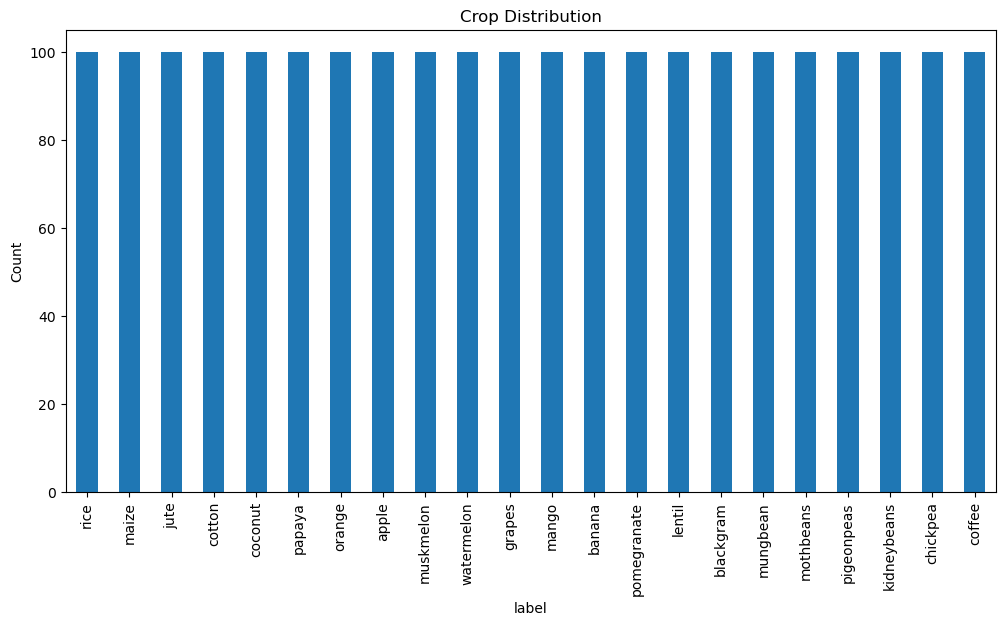

In [12]:
crop_df["label"].value_counts().plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Crop Distribution")
plt.ylabel("Count")
plt.show()

### Temperature Distribution

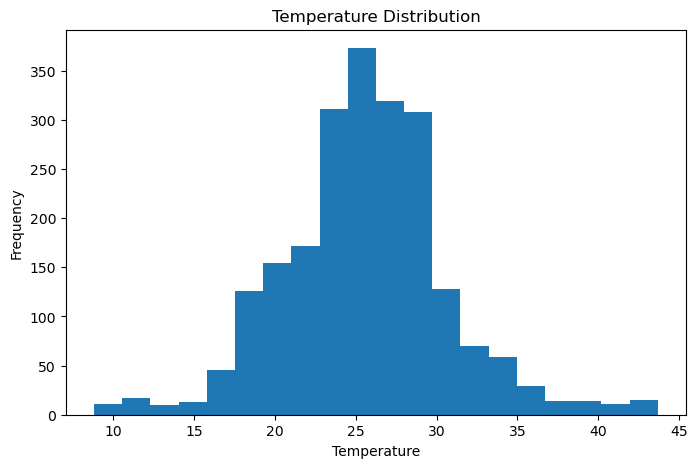

In [13]:
plt.figure(figsize=(8,5))
plt.hist(
    crop_df['temperature'],
    bins=20
)
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

### Rainfall Distribution

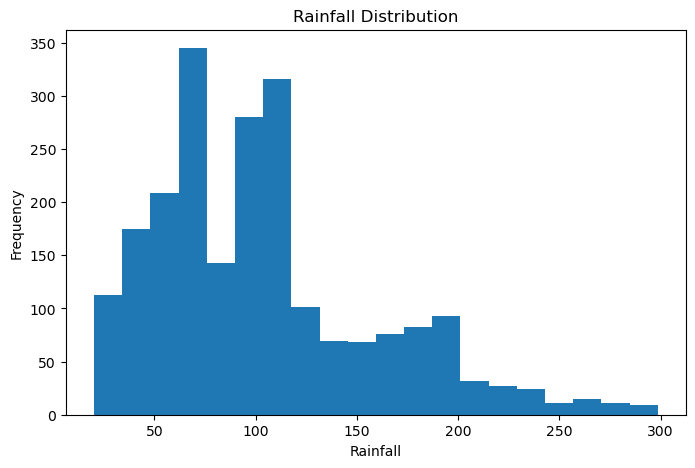

In [14]:
plt.figure(figsize=(8,5))
plt.hist(
    crop_df['rainfall'],
    bins=20
)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.show()

### Correlation matrix

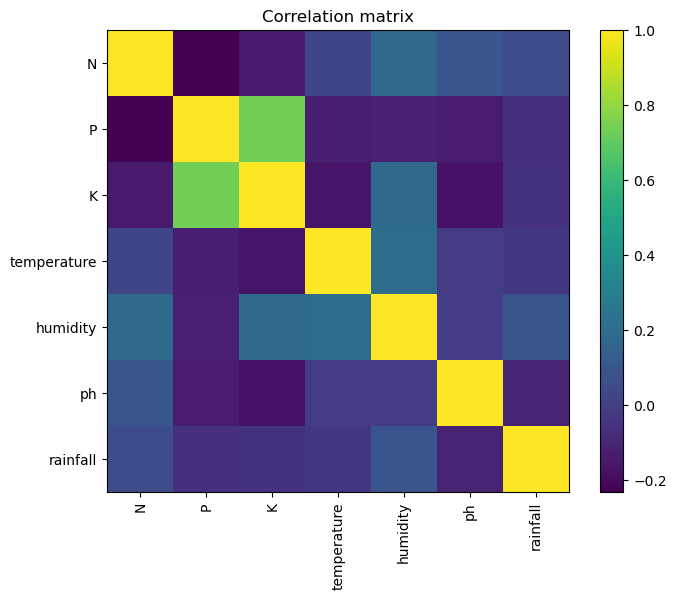

In [15]:
corr=crop_df.drop("label",axis=1).corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.title("Correlation matrix")

plt.show()

In [16]:
X_crop=crop_df.drop("label",axis=1)
y_crop=crop_df['label']

In [17]:
X_train_crop, X_test_crop, y_train_crop, y_test_crop = train_test_split(
    X_crop,
    y_crop,
    test_size=0.20,
    random_state=42,
    stratify=y_crop
)

### Decision tree classification

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
dt_crop = DecisionTreeClassifier(random_state=42)

dt_crop.fit(
    X_train_crop,
    y_train_crop
)

dt_pred = dt_crop.predict(X_test_crop)

### Random forest classification

In [23]:
rf_crop = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_crop.fit(
    X_train_crop,
    y_train_crop
)

rf_pred = rf_crop.predict(X_test_crop)

In [24]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(y_test_crop,dt_pred),

        accuracy_score(y_test_crop,rf_pred)

    ]

})

comparison

,Model,Accuracy
0,Decision Tree,0.979545
1,Random Forest,0.995455


In [25]:
print(classification_report(
    y_test_crop,
    rf_pred
))


              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

### Feature importance

In [26]:
importance = pd.DataFrame({

    "Feature":X_crop.columns,

    "Importance":rf_crop.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
6,rainfall,0.219641
4,humidity,0.217058
2,K,0.180813
1,P,0.151342
0,N,0.103356
3,temperature,0.075485
5,ph,0.052305


In [ ]:
import joblib

joblib.dump(
    rf_crop,
    "../models/crop_recommendation_model.pkl"
)